# **Inferencia de tópicos por sentimento**

In [1]:
# ==========================================
# Importação de bibliotecas e configuração de ambiente
# ==========================================
import pandas as pd
from pandas import DataFrame

import numpy as np
import seaborn as sns
from collections import Counter
from collections import defaultdict
import tabulate
from pathlib import Path
import pickle
import os
import time
from IPython.display import display

import spacy
import scipy.sparse

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, silhouette_score
from sklearn.cluster import KMeans

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
pyLDAvis.enable_notebook()

import gensim
from gensim import corpora, models
from gensim.models.ldamodel import LdaModel
from gensim.models import CoherenceModel, Word2Vec
from gensim.corpora import Dictionary
from gensim import matutils, models
from gensim.models import TfidfModel

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\win11\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# ==========================================
# mostra o texto completo em cada célula
# ==========================================
pd.set_option("display.max_colwidth", None)  

In [13]:
# ==========================================
# Carrega a base de dados
# ==========================================
df = pd.read_pickle("Reviews_Lisboa_RJ_200K.pkl")
print(f"A base de dados tem dimensões: {df.shape}")

A base de dados tem dimensões: (200000, 11)


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   date               200000 non-null  str   
 1   comments           200000 non-null  str   
 2   cidade             200000 non-null  str   
 3   lang               200000 non-null  str   
 4   char_count         200000 non-null  int64 
 5   word_count         200000 non-null  int64 
 6   texto_limpo        200000 non-null  str   
 7   nomes_proprios     200000 non-null  object
 8   texto_anonimizado  200000 non-null  str   
 9   texto_normalizado  200000 non-null  str   
 10  texto_lematizado   200000 non-null  str   
dtypes: int64(2), object(1), str(8)
memory usage: 16.8+ MB


In [4]:
df.head()

,date,comments,cidade,lang,char_count,word_count,texto_limpo,nomes_proprios,texto_anonimizado,texto_normalizado,texto_lematizado
0,2025-06-23,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada",Rio de Janeiro,pt,217,35,Os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,[],Os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,anfitrião maravilhoso casa charme macaquinho manhã varanda considerar móvel velho objeto pessoal acabar ficar cheiro forte guardar fechar
1,2022-05-02,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje .<br/>Vou falar 4 coisas que não poderia deixar passar.<br/>01- A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional.<br/>02- A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça.<br/>03- A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas.<br/>04- A localização do apartamento é fantástica pois fica pórximo a tudo.<br/>Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico !!!",Rio de Janeiro,pt,751,128,A estadia com o Renato foi a melhor experiência no Airbnb até hoje Vou falar coisas que não poderia deixar passar A vista da cobertura é sensacional um ângulo de visão da Bahia de Guanabara Pão de Açucar Aeroporto Santos Dumont e Cristo Redentor é sensacional A recepção no Chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça A flexibilidade na reserva e as dicas do RJ que o Renato passa são maravilhosas A localização do apartamento é fantástica pois fica pórximo a tudo Enfim Super indico o Renato para se hospedarem o Apartamento é fantastico,"[Renato, Renato, Renato]",A estadia com o host_anfitriao foi a melhor experiência no Airbnb até hoje Vou falar coisas que não poderia deixar passar A vista da cobertura é sensacional um ângulo de visão da Bahia de Guanabara Pão de Açucar Aeroporto Santos Dumont e Cristo Redentor é sensacional A recepção no Chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça A flexibilidade na reserva e as dicas do RJ que o host_anfitriao passa são maravilhosas A localização do apartamento é fantástica pois fica pórximo a tudo Enfim Super indico o host_anfitriao para se hospedarem o Apartamento é fantastico,a estadia com o host_anfitriao foi a melhor experiência no airbnb até hoje vou falar coisas que não poderia deixar passar a vista da cobertura é sensacional um ângulo de visão da bahia de guanabara pão de açucar aeroporto santos dumont e cristo redentor é sensacional a recepção no chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça a flexibilidade na reserva e as dicas do rj que o host_anfitriao passa são maravilhosas a localização do apartamento é fantástica pois fica pórximo

In [4]:
df['n_palavras'] = df['texto_limpo'].fillna('').str.split().str.len()
media_palavras_review = df['n_palavras'].mean()

print(media_palavras_review)

33.71899


In [5]:
df['n_palavras'] = df['texto_limpo'].fillna('').str.split().str.len()

comparacao_cidades = (
    df.groupby('cidade')
      .agg(
          n_reviews=('texto_limpo', 'size'),
          media_palavras=('n_palavras', 'mean')
      )
      .reset_index()
      .sort_values('media_palavras', ascending=False)
)

display(comparacao_cidades)

,cidade,n_reviews,media_palavras
1,Rio de Janeiro,100000,34.05179
0,Lisboa,100000,33.38619


In [8]:
df['n_palavras'] = df['texto_limpo'].fillna('').str.split().str.len()

total_palavras_por_cidade = (
    df.groupby('cidade')['n_palavras']
      .sum()
      .reset_index(name='total_palavras')
      .sort_values('total_palavras', ascending=False)
)

display(total_palavras_por_cidade)

,cidade,total_palavras
1,Rio de Janeiro,3405179
0,Lisboa,3338619


In [6]:
df['n_tokens'] = df['texto_lematizado'].fillna('').str.split().str.len()
media_tokens_review = df['n_tokens'].mean()

display(media_tokens_review)

np.float64(15.814545)

In [7]:
df['n_tokens'] = df['texto_lematizado'].fillna('').str.split().str.len()

comparacao_cidades_tokens = (
    df.groupby('cidade')
      .agg(
          n_reviews=('texto_lematizado', 'size'),
          media_tokens=('n_tokens', 'mean')
      )
      .reset_index()
      .sort_values('media_tokens', ascending=False)
)

display(comparacao_cidades_tokens)

,cidade,n_reviews,media_tokens
1,Rio de Janeiro,100000,16.10219
0,Lisboa,100000,15.52690


In [9]:
df_sent = pd.read_pickle("Reviews_BERTimbau_stevillis.pkl")
df_sent.head()

,date,comments,cidade,lang,texto_limpo,Base-analise_sentimento,Base-sentimento,Base-confianca,Stev_analise_sentimento,Stev-sentimento,Stev-confianca
0,2025-06-23,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada",Rio de Janeiro,pt,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada","{'label': 'POSITIVO', 'score': 0.4085640013217926}",POSITIVO,0.408564,"{'label': 'positive', 'score': 0.964259922504425}",positive,0.964260
1,2022-05-02,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje .<br/>Vou falar 4 coisas que não poderia deixar passar.<br/>01- A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional.<br/>02- A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça.<br/>03- A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas.<br/>04- A localização do apartamento é fantástica pois fica pórximo a tudo.<br/>Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico !!!",Rio de Janeiro,pt,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje . Vou falar coisas que não poderia deixar passar. - A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional. - A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça. - A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas. - A localização do apartamento é fantástica pois fica pórximo a tudo. Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico ! ! !","{'label': 'NEGATIVO', 'score': 0.4087783396244049}",NEGATIVO,0.408778,"{'label': 'positive', 'score': 0.9942275285720825}",positive,0.994228
2,2025-08-18,"o apt do Maurício é otimo!!! tudo nele nos encantou. o prédio, os porteiros, o apt, a gentileza, a localização, enfim, um lugar com a cara do Rio e da gentileza e bom gosto do carioca",Rio de Janeiro,pt,"o apt do Maurício é otimo! ! ! tudo nele nos encantou. o prédio, os porteiros, o apt, a gentileza, a localização, enfim, um lugar com a cara do Rio e da gentileza e bom gosto do carioca","{'label': 'NEGATIVO', 'score': 0.4266848862171173}",NEGATIVO,0.426685,"{'label': 'positive', 'score': 0.9974761605262756}",positive,0.997476
3,2024-05-02,"muito organizado, bonito, limpo, funcional. anfitrião atencioso, os melhores horários de check-in e checkout que já vi. gelo, café, toalhas, roupa de cama tudo que precisei tinha. Supermercado e farmácia perto, excelente. a vila estava um pouco barulhenta a noite, mas entendo que isso está fora do controle do anfitrião. umica recomendação seria um insulfim espelhado na porta. mas pq eu sou mais sensível a claridade mesmo.",Rio de Janeiro,pt,"muito organizado, bonito, limpo, funcional. anfitrião atencioso, os melhores horários de check-in e checkout que já vi. gelo, café, toalhas, roupa de cama tudo que precisei tinha. Supermercado e farmácia perto, excelente. a vila estava um pouco barulhenta a noite, mas entendo que isso está fora do controle do anfitrião. umica recomendação seria um insulfim espelhado na porta. mas pq eu sou mais sensível a claridade mesmo.","{'label': 'NEGATIVO', 'score': 0.40583062171936035}",NEGATIVO,0.405831,"{'label': 'positive', 'score': 0.9154902696609497}",positive,0.915490
4,2024-09-17,

In [8]:
df_sent.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   date                     200000 non-null  str    
 1   comments                 200000 non-null  str    
 2   cidade                   200000 non-null  str    
 3   lang                     200000 non-null  str    
 4   texto_limpo              200000 non-null  str    
 5   Base-analise_sentimento  200000 non-null  object 
 6   Base-sentimento          200000 non-null  str    
 7   Base-confianca           200000 non-null  float64
 8   Stev_analise_sentimento  200000 non-null  object 
 9   Stev-sentimento          200000 non-null  str    
 10  Stev-confianca           200000 non-null  float64
dtypes: float64(2), object(2), str(7)
memory usage: 60.8+ MB


------------
## Verificar se os dois datasets sao iguais
--------------

In [17]:
# 1) Verificar se têm as mesmas colunas
mesmas_colunas = set(df.columns) == set(df_sent.columns)

# 2) Verificar se têm as mesmas linhas, ignorando a ordem das linhas
mesmas_linhas = df.equals(df_sent)

# 3) Se quiser comparar só as colunas em comum
colunas_comuns = ['comments', 'date', 'cidade']

mesmos_dados_comuns = df[colunas_comuns].equals(df_sent[colunas_comuns])

print("Mesmas colunas:", mesmas_colunas)
print("Mesmas linhas:", mesmas_linhas)
print("Mesmos dados nas colunas comuns:", mesmos_dados_comuns)

Mesmas colunas: False
Mesmas linhas: False
Mesmos dados nas colunas comuns: True


In [18]:
colunas_comuns = ['comments', 'date', 'cidade']

colunas_so_no_df = set(df.columns) - set(df_sent.columns)
colunas_so_no_df_sent = set(df_sent.columns) - set(df.columns)

print("Só no df:", colunas_so_no_df)
print("Só no df_sent:", colunas_so_no_df_sent)

df_comum = df[colunas_comuns].sort_values(colunas_comuns).reset_index(drop=True)
df_sent_comum = df_sent[colunas_comuns].sort_values(colunas_comuns).reset_index(drop=True)

print("Dados comuns iguais:", df_comum.equals(df_sent_comum))

Só no df: {'nomes_proprios', 'texto_lematizado', 'texto_anonimizado', 'char_count', 'word_count', 'texto_normalizado'}
Só no df_sent: {'Base-confianca', 'Base-sentimento', 'Stev-sentimento', 'Stev-confianca', 'Base-analise_sentimento', 'Stev_analise_sentimento'}
Dados comuns iguais: True


-----------
# Fazer a juncao da coluna "Stev-sentimento" do dataset "Reviews_BERTimbau_stevillis.pkl" para o dataset "Reviews_Lisboa_RJ_200K.pkl" atravéz da coluna "comments"
------------

In [10]:
import pandas as pd

# Criar chaves normalizadas para reduzir problemas com espaços
df['comments_key'] = df['comments'].astype(str).str.strip()
df_sent['comments_key'] = df_sent['comments'].astype(str).str.strip()

# Verificar se os comentários coincidem entre os dois datasets
verificacao = df[['comments_key']].merge(
    df_sent[['comments_key']],
    on='comments_key',
    how='outer',
    indicator=True
)

print(verificacao['_merge'].value_counts())

# Juntar mantendo todas as colunas de df e acrescentando apenas Stev-sentimento
df_final = df.merge(
    df_sent[['comments_key', 'Stev-sentimento']],
    on='comments_key',
    how='left'
)

# Remover a coluna auxiliar
df_final = df_final.drop(columns=['comments_key'])

df_final.info()

# Guardar o resultado
# df_final.to_csv('df_com_stev_sentimento.csv', index=False)

_merge
both          640494
left_only          0
right_only         0
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 640494 entries, 0 to 640493
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   date               640494 non-null  str   
 1   comments           640494 non-null  str   
 2   cidade             640494 non-null  str   
 3   lang               640494 non-null  str   
 4   char_count         640494 non-null  int64 
 5   word_count         640494 non-null  int64 
 6   texto_limpo        640494 non-null  str   
 7   nomes_proprios     640494 non-null  object
 8   texto_anonimizado  640494 non-null  str   
 9   texto_normalizado  640494 non-null  str   
 10  texto_lematizado   640494 non-null  str   
 11  Stev-sentimento    640494 non-null  str   
dtypes: int64(2), object(1), str(9)
memory usage: 63.6+ MB


In [5]:
df_topic_sent = df.merge(
    df_sent[['comments', 'Stev-sentimento']],
    on='comments',
    how='left'
)

In [8]:
df_topic_sent.head()

,date,comments,cidade,lang,char_count,word_count,texto_limpo,nomes_proprios,texto_anonimizado,texto_normalizado,texto_lematizado,Stev-sentimento
0,2025-06-23,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada",Rio de Janeiro,pt,217,35,Os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,[],Os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,anfitrião maravilhoso casa charme macaquinho manhã varanda considerar móvel velho objeto pessoal acabar ficar cheiro forte guardar fechar,positive
1,2022-05-02,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje .<br/>Vou falar 4 coisas que não poderia deixar passar.<br/>01- A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional.<br/>02- A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça.<br/>03- A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas.<br/>04- A localização do apartamento é fantástica pois fica pórximo a tudo.<br/>Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico !!!",Rio de Janeiro,pt,751,128,A estadia com o Renato foi a melhor experiência no Airbnb até hoje Vou falar coisas que não poderia deixar passar A vista da cobertura é sensacional um ângulo de visão da Bahia de Guanabara Pão de Açucar Aeroporto Santos Dumont e Cristo Redentor é sensacional A recepção no Chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça A flexibilidade na reserva e as dicas do RJ que o Renato passa são maravilhosas A localização do apartamento é fantástica pois fica pórximo a tudo Enfim Super indico o Renato para se hospedarem o Apartamento é fantastico,"[Renato, Renato, Renato]",A estadia com o host_anfitriao foi a melhor experiência no Airbnb até hoje Vou falar coisas que não poderia deixar passar A vista da cobertura é sensacional um ângulo de visão da Bahia de Guanabara Pão de Açucar Aeroporto Santos Dumont e Cristo Redentor é sensacional A recepção no Chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça A flexibilidade na reserva e as dicas do RJ que o host_anfitriao passa são maravilhosas A localização do apartamento é fantástica pois fica pórximo a tudo Enfim Super indico o host_anfitriao para se hospedarem o Apartamento é fantastico,a estadia com o host_anfitriao foi a melhor experiência no airbnb até hoje vou falar coisas que não poderia deixar passar a vista da cobertura é sensacional um ângulo de visão da bahia de guanabara pão de açucar aeroporto santos dumont e cristo redentor é sensacional a recepção no chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça a flexibilidade na reserva e as dicas do rj que o host_anfitriao passa são maravilhosas a localização do apartamento é fan

In [6]:
df_topic_sent.info()

<class 'pandas.DataFrame'>
RangeIndex: 636720 entries, 0 to 636719
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   date               636720 non-null  str   
 1   comments           636720 non-null  str   
 2   cidade             636720 non-null  str   
 3   lang               636720 non-null  str   
 4   char_count         636720 non-null  int64 
 5   word_count         636720 non-null  int64 
 6   texto_limpo        636720 non-null  str   
 7   nomes_proprios     636720 non-null  object
 8   texto_anonimizado  636720 non-null  str   
 9   texto_normalizado  636720 non-null  str   
 10  texto_lematizado   636720 non-null  str   
 11  Stev-sentimento    636720 non-null  str   
dtypes: int64(2), object(1), str(9)
memory usage: 63.2+ MB


----------
# Analise de Sentimento por Tópico
--------------

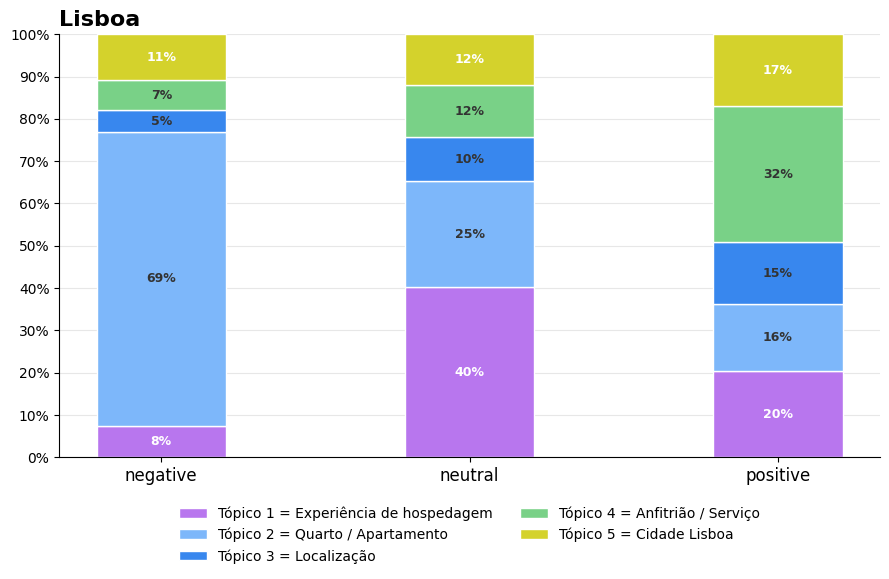

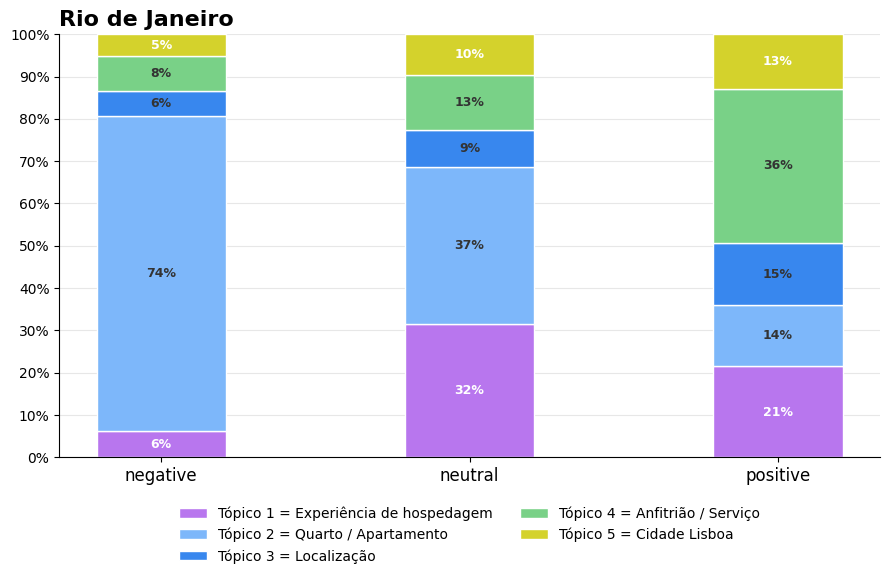

Ficheiros gerados:
output\grafico_Lisboa.png
output\grafico_Rio de Janeiro.png


In [ ]:
# =========================================================
# 1. Caminhos
# =========================================================
models_dir = Path("LDA_9-models")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# =========================================================
# 2. Carregar modelo LDA e dicionário
# =========================================================
lda_file = models_dir / "ldamodel_5topics.model"
dict_file = models_dir / "ldamodel_5topics.model.id2word"

lda = gensim.models.ldamodel.LdaModel.load(str(lda_file))
dictionary = corpora.Dictionary.load(str(dict_file))

# =========================================================
# 3. Preparar os textos
# =========================================================
work = df_topic_sent.copy()
work["texto_lematizado_tokens"] = work["texto_lematizado"].astype(str).apply(lambda x: x.split())

# =========================================================
# 4. Converter para Bag-of-Words
# =========================================================
corpus = [dictionary.doc2bow(tokens) for tokens in work["texto_lematizado_tokens"]]

# =========================================================
# 5. Inferir distribuição de tópicos por documento
# =========================================================
doc_topics = [lda.get_document_topics(bow, minimum_probability=0.0) for bow in corpus]

topic_cols = [f"topico_{i}" for i in range(lda.num_topics)]
topic_matrix = []

for doc in doc_topics:
    row = [0.0] * lda.num_topics
    for topic_id, prob in doc:
        row[topic_id] = prob
    topic_matrix.append(row)

topic_df = pd.DataFrame(topic_matrix, columns=topic_cols)

# =========================================================
# 6. Juntar ao dataframe original
# =========================================================
df_final = pd.concat([work.reset_index(drop=True), topic_df.reset_index(drop=True)], axis=1)

# =========================================================
# 7. Configuração
# =========================================================
cidade_col = "cidade"
sentimento_col = "Stev-sentimento"

df_final["sent_plot"] = df_final[sentimento_col].astype(str).str.lower().str.strip()
sent_order = ["negative", "neutral", "positive"]

nomes_topicos = {
    "topico_0": "Tópico 1 = Experiência de hospedagem",
    "topico_1": "Tópico 2 = Quarto / Apartamento",
    "topico_2": "Tópico 3 = Localização",
    "topico_3": "Tópico 4 = Anfitrião / Serviço",
    "topico_4": "Tópico 5 = Cidade Lisboa"
}

cores = ["#B876EE", "#7DB7FA", "#3887EE", "#79D187", "#D4D22C"]

# =========================================================
# 8. Selecionar cidades
# =========================================================
cities = [c for c in ["Lisboa", "Rio de Janeiro"] if c in df_final[cidade_col].astype(str).unique()]

# =========================================================
# 9. Função para criar e guardar um gráfico por cidade
# =========================================================
def salvar_grafico_cidade(df, city_name):
    d = df[df[cidade_col].astype(str) == city_name].copy()
    d = d[d["sent_plot"].isin(sent_order)].copy()

    mean_tab = d.groupby("sent_plot")[topic_cols].mean().reindex(sent_order).fillna(0)    # Faz a média dos tópicos por sentimento e reordena conforme sent_order
    row_sums = mean_tab.sum(axis=1).replace(0, np.nan)
    tab_pct = mean_tab.div(row_sums, axis=0).fillna(0) * 100

    fig, ax = plt.subplots(figsize=(9, 6))

    x = np.arange(len(sent_order))
    bottom = np.zeros(len(sent_order))

    for i, topic in enumerate(topic_cols):
        vals = tab_pct[topic].values

        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.42,
            color=cores[i],
            edgecolor="white",
            label=nomes_topicos.get(topic, topic)
        )

        for j, v in enumerate(vals):
            if v >= 1:
                ax.text(
                    x[j],
                    bottom[j] + v / 2,
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="white" if i in [0, 4] else "#333333",
                    fontweight="bold"
                )

        bottom += vals

    ax.set_title(city_name, fontsize=16, fontweight="bold", loc="left")
    ax.set_xticks(x)
    ax.set_xticklabels(sent_order, fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 10))
    ax.set_yticklabels([f"{i}%" for i in range(0, 101, 10)])
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, -0.28),
        ncol=2,
        frameon=False
    )

    plt.tight_layout()

    file_name = city_name
    fig_path = output_dir / f"grafico_{file_name}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return fig_path

# =========================================================
# 10. Gerar gráficos separados
# =========================================================
saved_files = []
for city in cities:
    saved_files.append(salvar_grafico_cidade(df_final, city))


print("Ficheiros gerados:")
for f in saved_files:
    print(f)

